# 분류 모델 비교 (Wine Dataset)

LogisticRegression, SVM, DecisionTree, RandomForest 4가지 모델을 **동일한 데이터, 동일한 전처리, 동일한 평가 기준**으로 비교합니다.

**공통 파이프라인:**
1. 데이터 로드 및 확인
2. 학습/테스트 분할 (test_size=0.3, random_state=42)
3. StandardScaler 적용
4. 모델 학습
5. Train/Test Score 출력
6. Classification Report 출력
7. Confusion Matrix 시각화

---
## 0. 공통 셋업 (Import, 데이터 로드, 전처리)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 공통 평가·시각화: utils.py (이 노트북과 다른 실습 노트북에서 동일하게 사용)
from utils import evaluate_cls_model, plot_cm

In [3]:
# 데이터 로드 (wine - 이진 분류: 레드와인 0 / 화이트와인 1)
df = pd.read_csv('./dataset/wine.csv')

X = df[df.columns[:-1]].values
y = df['class'].values

print(f"데이터 shape: {df.shape}")
print(f"클래스 분포: {np.unique(y, return_counts=True)}")
df.head()

데이터 shape: (6497, 4)
클래스 분포: (array([0., 1.]), array([1599, 4898]))


,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [4]:
# 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# StandardScaler 적용
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

Train: (4547, 3), Test: (1950, 3)


---
## 1. Logistic Regression

- 이진/다중 분류 모두 가능한 기본 분류 모델
- 시그모이드 함수로 확률값(0~1) 출력 → 임계값 기준으로 분류
- **스케일링 권장** (규제 파라미터 C 사용)
- 해석이 쉽고 빠르지만, 비선형 관계 학습에 한계

In [5]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = evaluate_cls_model(lr, X_train_scaled, X_test_scaled, y_train, y_test, "LogisticRegression")

=== LogisticRegression ===
Train Score: 0.7843
Test  Score: 0.7713

              precision    recall  f1-score   support

         0.0       0.59      0.36      0.45       502
         1.0       0.80      0.91      0.86      1448

    accuracy                           0.77      1950
   macro avg       0.70      0.64      0.65      1950
weighted avg       0.75      0.77      0.75      1950



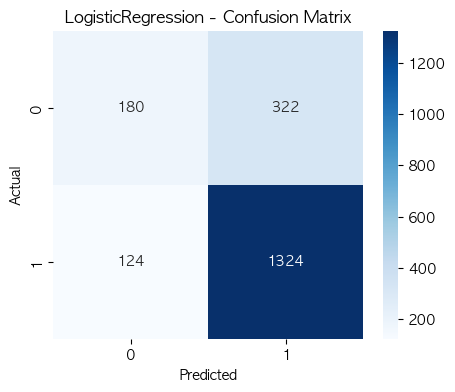

In [6]:
plot_cm(y_test, y_pred_lr, "LogisticRegression")

---
## 2. SVM (Support Vector Machine)

- 클래스 간 **마진을 최대화**하는 결정 경계(초평면) 생성
- 커널 트릭으로 비선형 분류도 가능 (`rbf`, `poly` 등)
- **스케일링 필수** (거리 기반 알고리즘)
- 소~중규모 데이터에서 강력한 성능

In [7]:
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred_svm = evaluate_cls_model(svm, X_train_scaled, X_test_scaled, y_train, y_test, "SVM (RBF)")

=== SVM (RBF) ===
Train Score: 0.8300
Test  Score: 0.8138

              precision    recall  f1-score   support

         0.0       0.68      0.53      0.60       502
         1.0       0.85      0.91      0.88      1448

    accuracy                           0.81      1950
   macro avg       0.76      0.72      0.74      1950
weighted avg       0.80      0.81      0.81      1950



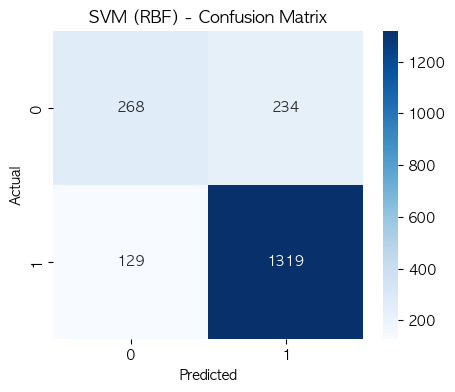

In [8]:
plot_cm(y_test, y_pred_svm, "SVM (RBF)")

---
## 3. DecisionTree

- **분기(if-else)** 기반으로 데이터를 분할하여 분류
- 지니 불순도 / 엔트로피가 감소하는 방향으로 분할
- **스케일링 불필요** (트리 기반)
- 해석이 쉬움 (시각화 가능), 하지만 과적합에 취약

In [9]:
# 트리 기반 모델은 스케일링 불필요하지만, 비교 공정성을 위해 동일 데이터 사용
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = evaluate_cls_model(dt, X_train, X_test, y_train, y_test, "DecisionTree")

=== DecisionTree ===
Train Score: 0.8720
Test  Score: 0.8621

              precision    recall  f1-score   support

         0.0       0.72      0.75      0.74       502
         1.0       0.91      0.90      0.91      1448

    accuracy                           0.86      1950
   macro avg       0.82      0.83      0.82      1950
weighted avg       0.86      0.86      0.86      1950



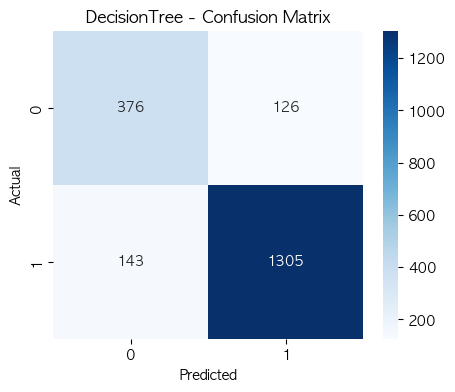

In [10]:
plot_cm(y_test, y_pred_dt, "DecisionTree")

---
## 4. RandomForest

- 여러 개의 결정 트리를 **배깅(Bagging)**으로 앙상블
- 각 트리는 부트스트랩 샘플 + 랜덤 feature 부분집합으로 학습
- **스케일링 불필요** (트리 기반)
- 과적합에 강하고, feature 중요도 제공

In [11]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = evaluate_cls_model(rf, X_train, X_test, y_train, y_test, "RandomForest")

=== RandomForest ===
Train Score: 0.9397
Test  Score: 0.8692

              precision    recall  f1-score   support

         0.0       0.75      0.74      0.74       502
         1.0       0.91      0.92      0.91      1448

    accuracy                           0.87      1950
   macro avg       0.83      0.83      0.83      1950
weighted avg       0.87      0.87      0.87      1950



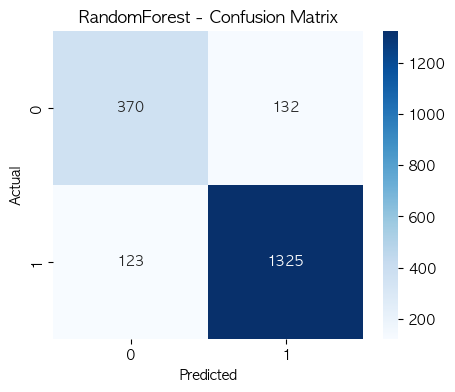

In [12]:
plot_cm(y_test, y_pred_rf, "RandomForest")

---
## 5. 모델 비교 요약

In [13]:
# 모든 모델 성능을 한눈에 비교
models = {
    "LogisticRegression": (lr, X_train_scaled, X_test_scaled, y_pred_lr),
    "SVM (RBF)": (svm, X_train_scaled, X_test_scaled, y_pred_svm),
    "DecisionTree": (dt, X_train, X_test, y_pred_dt),
    "RandomForest": (rf, X_train, X_test, y_pred_rf),
}

summary = []
for name, (model, Xtr, Xte, y_pred) in models.items():
    summary.append({
        "Model": name,
        "Train Accuracy": model.score(Xtr, y_train),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score (weighted)": f1_score(y_test, y_pred, average='weighted'),
    })

df_summary = pd.DataFrame(summary).set_index("Model")
df_summary.round(4)

,Train Accuracy,Test Accuracy,F1 Score (weighted)
Model,,,
LogisticRegression,0.7843,0.7713,0.7505
SVM (RBF),0.8300,0.8138,0.8062
DecisionTree,0.8720,0.8621,0.8628
RandomForest,0.9397,0.8692,0.8688


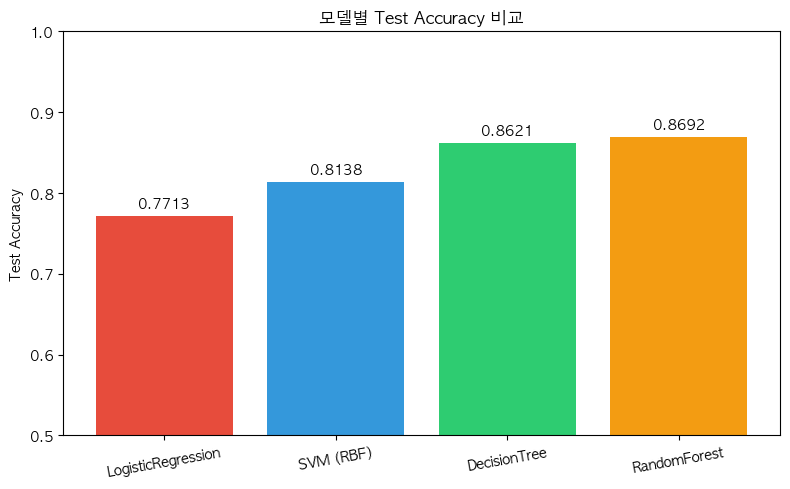

In [14]:
# Test Accuracy 비교 시각화
plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
plt.bar(df_summary.index, df_summary["Test Accuracy"], color=colors)
plt.ylabel("Test Accuracy")
plt.title("모델별 Test Accuracy 비교")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=10)
for i, v in enumerate(df_summary["Test Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 모델별 특성 정리

| 구분 | LogisticRegression | SVM | DecisionTree | RandomForest |
|------|-------------------|-----|-------------|-------------|
| **원리** | 시그모이드 확률 | 마진 최대화 | 분기(if-else) | 트리 앙상블 |
| **스케일링** | 권장 | 필수 | 불필요 | 불필요 |
| **비선형 학습** | 제한적 | 커널로 가능 | 가능 | 가능 |
| **과적합 위험** | 낮음 | 낮음 | **높음** | 낮음 |
| **해석 가능성** | 계수 해석 | 어려움 | **트리 시각화** | feature 중요도 |
| **대규모 데이터** | 빠름 | 느림 | 빠름 | 보통 |